In [114]:
import os
import pandas as pd
import numpy as np
import us

import geopandas as gpd
import plotly as plt
import plotly.express as px

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import bokeh
from bokeh.plotting import figure, show
from bokeh.layouts import gridplot
from ipywidgets import interact, interact_manual
import pandas_datareader.data as web
from bokeh.models import HoverTool, Panel, Tabs

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_colwidth', 500)
pd.set_option('display.width', 500)
pd.options.display.float_format = '{:.2f}'.format

os.chdir(r'E:/Dropbox (Personal)/project/muni_bonds')

# Municipal bond issuance by state


In [103]:
""" Read data """
# read issuer-month level muni bonds amount outstanding
base = pd.read_csv('./data_old/processed/muni_issuer_month_bonds.csv')
print("Read issuer-month level muni amount oustanding:", base.shape, base['date_m'].min(), base['date_m'].max())

# read geojson data
county = gpd.read_file('./data/raw/counties.geojson')
state = gpd.read_file('./data/raw/gz_2010_us_040_00_500k.json')

Read issuer-month level muni amount oustanding: (1231952, 16) 1980-02 2025-12


In [126]:
""" Aggregate to state-year level """
# map state fips
base['state_abbr'] = base['muni_issuer_id'].str[:2]
base['state_fips'] = base['state_abbr'].map(lambda abbr: us.states.lookup(abbr).fips)

# sum up all the amt_new_iss per state-year
base['issuance_mm'] = base['amt_new_iss'] / 1000000
f = {'state_abbr':'last', 'amt_new_iss':'sum', 'issuance_mm':'sum', 'num_new_iss':'sum'}
base_sy = base.groupby(['state_fips', 'year'], as_index=False).agg(f)
print("After aggregating to state-year level:", base_sy.shape)

# add geometry
base_sy = pd.merge(base_sy.copy(), state.copy(), left_on=['state_fips'], right_on=['STATE'], how='left')
print("After adding geometry:", base_sy.shape)

After aggregating to state-year level: (2270, 6)
After adding geometry: (2270, 12)


## Cross check with industry data

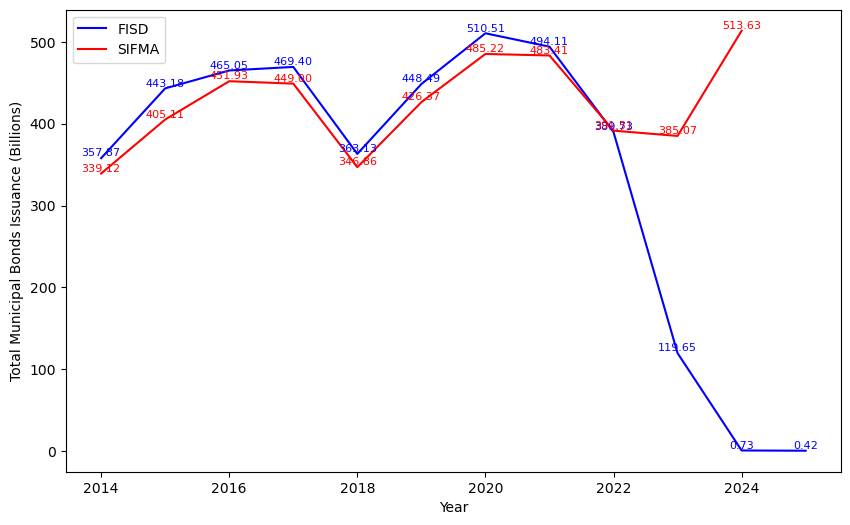

In [123]:
""" Cross check my data with industry reports """
" Read industry data "
sifma_iss = pd.read_excel('./data/raw/US-Municipal-Bonds-Statistics-SIFMA.xlsx', sheet_name=1, skiprows=8)
sifma_iss = sifma_iss.rename(columns={'Unnamed: 0':'year'})
sifma_iss = sifma_iss.head(11)

sifma_out = pd.read_excel('./data/raw/US-Municipal-Bonds-Statistics-SIFMA.xlsx', sheet_name=4, skiprows=7)
sifma_out = sifma_out.rename(columns={'Unnamed: 0':'year'})
sifma_out = sifma_out.head(11)

" Cross check "
base_sy['issuance_bn'] = base_sy['issuance_mm'] / 1000
f = {'issuance_bn':'sum'}
base_y = base_sy.groupby(['year'], as_index=False).agg(f)
base_y = base_y.loc[base_y['year']>=2014]

plt.figure(figsize=(10, 6))
plt.plot(base_y['year'], base_y['issuance_bn'], color='blue', label='Mergent')
plt.plot(sifma_iss['year'], sifma_iss['Total'], color='red', label='SIFMA')

for x, y in zip(base_y['year'], base_y['issuance_bn']):
    plt.text(x, y, f'{y:.2f}', fontsize=8, color='blue', ha='center', va='bottom')

for x, y in zip(sifma_iss['year'], sifma_iss['Total']):
    plt.text(x, y, f'{y:.2f}', fontsize=8, color='red', ha='center', va='bottom')

plt.xlabel('Year')
plt.ylabel('Total Municipal Bonds Issuance (Billions)')
plt.legend()
plt.show()

## State level total issuance

In [148]:
""" Plot choropleth """
" New issuance "
years = base_sy['year'].sort_values().unique()

def plot_issuance(year):
    df = base_sy[base_sy['year']==year].copy()
    fig = px.choropleth(df,
                        geojson=state,
                        locations='STATE',
                        featureidkey="properties.STATE",
                        hover_name="NAME",
                        color="amt_new_iss",
                        color_continuous_scale='Reds',
                        range_color=(0, df['amt_new_iss'].quantile(0.99)),
                        scope="usa",
                        labels={'STATE': 'FIPS Code', 'amt_new_iss':'New issuance'})
    fig.update_layout(title_text='Municipal bond issuance by state: %s'%(year),
                      geo = dict(scope='usa', showland = True),
                      annotations = [dict(x=0.1, y=-0.1, xref='paper', yref='paper',
                                     text='Source: Mergent Municipal Bonds Database', showarrow = False)])
    fig.show()

@interact(year=years)
def make_plot_for(year=years[0]):
    plot = plot_issuance(year)
    return plot

interactive(children=(Dropdown(description='year', options=(np.int64(1980), np.int64(1981), np.int64(1982), np…

In [149]:
" Number of bonds "
years = base_sy['year'].sort_values().unique()

def plot_num_iss(year):
    df = base_sy[base_sy['year']==year].copy()
    fig = px.choropleth(df,
                        geojson=state,
                        locations='STATE',
                        featureidkey="properties.STATE",
                        hover_name="NAME",
                        color="num_new_iss",
                        color_continuous_scale='Reds',
                        range_color=(0, df['num_new_iss'].quantile(0.99)),
                        scope="usa",
                        labels={'STATE': 'FIPS Code', 'num_new_iss':'Number of newly issued bonds'})
    fig.update_layout(title_text='Number of unique municipal bonds newly issued by state: %s'%(year),
                      geo = dict(scope='usa', showland = True),
                      annotations = [dict(x=0.1, y=-0.1, xref='paper', yref='paper',
                                     text='Source: Mergent Municipal Bonds Database', showarrow = False)])
    fig.show()

@interact(year=years)
def make_plot_for(year=years[0]):
    plot = plot_num_iss(year)
    return plot

interactive(children=(Dropdown(description='year', options=(np.int64(1980), np.int64(1981), np.int64(1982), np…

## County level issuance

In [142]:
""" Aggregate to county-year level """
# county level issuance
base_c = base.loc[base['is_state']==0].copy()
base_c['county_fips'] = base_c['muni_issuer_id'].str[3:].astype(int)

# sum up all the amt_new_iss per county-year
f = {'amt_new_iss':'sum', 'issuance_mm':'sum', 'num_new_iss':'sum'}
base_cy = base_c.groupby(['county_fips', 'year'], as_index=False).agg(f)
print("After aggregating to county-year level:", base_cy.shape)

# add geometry
county['id'] = county['id'].astype(int)
base_cy = pd.merge(base_cy.copy(), county.copy(), left_on=['county_fips'], right_on=['id'], how='left')
print("After adding geometry:", base_cy.shape)

After aggregating to county-year level: (102115, 5)
After adding geometry: (102115, 13)


In [147]:
""" Plot choropleth """
" New issuance "
years = base_cy['year'].sort_values().unique()

def plot_issuance_c(year):
    df = base_cy[base_cy['year']==year].copy()
    fig = px.choropleth(df,
                        geojson=county,
                        locations='id',
                        featureidkey="properties.id",
                        hover_name="NAME",
                        color="amt_new_iss",
                        color_continuous_scale='Reds',
                        range_color=(0, df['amt_new_iss'].quantile(0.99)),
                        scope="usa",
                        labels={'id': 'FIPS Code', 'amt_new_iss':'New issuance'})
    fig.update_layout(title_text='Municipal bond issuance by county: %s'%(year),
                      geo = dict(scope='usa', showland = True),
                      annotations = [dict(x=0.1, y=-0.1, xref='paper', yref='paper',
                                     text='Source: Mergent Municipal Bonds Database', showarrow = False)])
    fig.show()

@interact(year=years)
def make_plot_for(year=years[0]):
    plot = plot_issuance_c(year)
    return plot

interactive(children=(Dropdown(description='year', options=(np.int64(1980), np.int64(1981), np.int64(1982), np…